In [5]:
%pip install sklearn
%pip install panelsplit


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached panelsplit-2.1.1-py3-none-any.whl (56 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/451.9 kB ? eta -:--:--
   ------------------------ --------------- 276.5/451.9 kB 5.7 MB/s eta 0:00:01
   ---------------------------------------  450.6/451.9 kB 7.1 MB/s eta 0:00:01
   ---------------------------------------  450.6/451.9 kB 7.1 MB/s eta 0:00:01
   ---------------------------------------  450.6/451.9 kB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 451.9/451.9 kB 2.0 MB/s eta 0:00:00
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached threadpoolctl-3.6.0-py


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from panelsplit.cross_validation import PanelSplit
from panelsplit.application import cross_val_fit_predict
from sklearn.ensemble import RandomForestClassifier


In [41]:
df = pd.read_csv('../data/final_panel_data.csv')
df = df.loc[df['isocode'] != 'KOR'].copy()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.set_index(['isocode', 'period']).sort_index()
print(df.shape)
df.head(3)
#tst


(6933, 30)


date  yield_10y  Competition and Sports  \
isocode period                                                 
AUS     201001 2010-01-01     5.5575                0.061398   
        201002 2010-02-01     5.4775                0.062448   
        201003 2010-03-01     5.6200                0.059424   

                Health and Education  Military Conflict  Politics  \
isocode period                                                      
AUS     201001              0.073588           0.019415  0.019441   
        201002              0.073145           0.020595  0.021634   
        201003              0.075694           0.019563  0.022156   

                Military Technology  National Development  Political Tensions  \
isocode period                                                                  
AUS     201001             0.031388              0.067876            0.110389   
        201002             0.036304              0.063547            0.114383   
        201003             0.035235              0.072683            0.113926   

                Judiciary and Abuses  ...        vix  brent_oil  \
isocode period                        ...                         
AUS     201001              0.090134  ...  24.620001  71.459999   
        201002              0.095505  ...  19.500000  77.589996   
        201003              0.100099  ...  17.590000  82.699997   

                credit_spread  inflation   fx_rate  ip  stock_index  \
isocode period                                                        
AUS     201001      33.675831        NaN  1.096781 NaN    100.00000   
        201002      34.042908        NaN  1.127445 NaN     92.23358   
        201003      34.778976        NaN  1.095715 NaN     99.37471   

                terms_of_trade  reserves       debt  
isocode period                                       
AUS     201001        1.000000  38864.08  19.242444  
        201002        1.023580  36759.20  19.242444  
        201003        1.059195  34988.19  19.242444  

[3 rows x 30 columns]

In [42]:
DEV_12M_THRESHOLD = 0.25
HORIZONS = [3, 6, 12]

g = df.groupby(level='isocode')

# Trailing 12m mean excluding current period — shift(1) before rolling is the leakage guard
trailing_mean_12m = g['yield_10y'].transform(
    lambda s: s.shift(1).rolling(12, min_periods=6).mean()
)
df['dev_from_mean_12m'] = df['yield_10y'] - trailing_mean_12m

# Current-period incidence
df['incidence'] = np.where(
    df['dev_from_mean_12m'].notna(),
    df['dev_from_mean_12m'] > DEV_12M_THRESHOLD,
    np.nan
)

# Onset: 0->1 transitions only
def make_onset(spike):
    prev = spike.shift(1)
    onset = (spike == True) & (prev.fillna(False) != True)
    onset = onset.astype(object)
    onset[spike.isna()] = np.nan
    return onset

df['onset'] = g['incidence'].transform(make_onset)

# Shift targets forward by each horizon (row t holds outcome at t+h)
for h in HORIZONS:
    df[f'y_incidence_{h}m'] = g['incidence'].transform(lambda s, h=h: s.shift(-h))
    df[f'y_onset_{h}m'] = g['onset'].transform(lambda s, h=h: s.shift(-h))

# Sanity check
print("Incidence rate (current):", df['incidence'].mean().round(3))
print("Onset rate (current):", df['onset'].mean().round(3))
for h in HORIZONS:
    print(f"  y_incidence_{h}m rate:", df[f'y_incidence_{h}m'].mean().round(3))
    print(f"  y_onset_{h}m rate:    ", df[f'y_onset_{h}m'].mean().round(3))


Incidence rate (current): 0.255
Onset rate (current): 0.041
  y_incidence_3m rate: 0.255
  y_onset_3m rate:     0.041
  y_incidence_6m rate: 0.255
  y_onset_6m rate:     0.041
  y_incidence_12m rate: 0.259
  y_onset_12m rate:     0.041


In [43]:
# Lags
for lag in [1, 3, 6, 12]:
    df[f'yield_lag{lag}'] = g['yield_10y'].transform(lambda s, l=lag: s.shift(l))

# Rolling means (includes current period — fine since yield[t] is known at t)
for w in [3, 6, 12, 36, 60]:
    df[f'yield_roll_mean{w}'] = g['yield_10y'].transform(
        lambda s, w=w: s.rolling(w, min_periods=max(1, w//2)).mean()
    )

# Dev from mean and its lags
df['dev_lag1'] = g['dev_from_mean_12m'].transform(lambda s: s.shift(1))
df['dev_lag3'] = g['dev_from_mean_12m'].transform(lambda s: s.shift(3))

# Since / ongoing on incidence
def count_since(x):
    x = list(x)
    y = []
    for n in range(len(x)):
        if x[n] == 1:
            y.append(0)
        elif n == 0:
            y.append(1)
        else:
            y.append(y[n-1] + 1)
    return y

def count_ongoing(x):
    x = list(x)
    y, ctr = [], 0
    for n in range(len(x)):
        if x[n] == 1:
            ctr += 1
            y.append(ctr)
        else:
            ctr = 0
            y.append(0)
    return y

incidence_binary = df['incidence'].fillna(0).astype(int)
df['since_spike'] = incidence_binary.groupby(level='isocode').transform(count_since)
df['ongoing_spike'] = incidence_binary.groupby(level='isocode').transform(count_ongoing)

print("Features created.")
df[['yield_lag1','yield_roll_mean12','dev_lag1','since_spike','ongoing_spike']].describe()


Features created.


,yield_lag1,yield_roll_mean12,dev_lag1,since_spike,ongoing_spike
count,6893.000000,6733.000000,6653.000000,6933.000000,6933.000000
mean,3.526137,3.510006,-0.035247,12.945190,1.726093
std,2.888523,2.851686,0.850849,15.988551,4.203199
min,-0.975000,-0.601167,-11.397500,0.000000,0.000000
25%,1.340000,1.336014,-0.396667,1.000000,0.000000
50%,2.980000,2.930106,-0.072277,8.000000,0.000000
75%,5.166661,5.216667,0.261667,20.000000,0.000000
max,29.240000,23.215000,12.309167,130.000000,26.000000


In [44]:
topic_cols = [
    'Competition and Sports', 'Health and Education', 'Military Conflict',
    'Politics', 'Military Technology', 'National Development',
    'Political Tensions', 'Judiciary and Abuses', 'Middle East',
    'Chinese Politics', 'Economics', 'Diplomacy', 'Civilian Life',
    'Foreign Policy', 'Power and Negotiation'
]

macro_cols = ['vix', 'brent_oil', 'credit_spread', 'fx_rate', 'inflation', 'ip', 'reserves', 'debt', 'stock_index']

yield_feature_cols = [
    'yield_10y',
    'yield_lag1', 'yield_lag3', 'yield_lag6', 'yield_lag12',
    'yield_roll_mean3', 'yield_roll_mean6', 'yield_roll_mean12',
    'yield_roll_mean36', 'yield_roll_mean60',
    'dev_from_mean_12m', 'dev_lag1', 'dev_lag3',
    'since_spike', 'ongoing_spike'
]

full_feature_cols = yield_feature_cols + topic_cols + macro_cols

print(f"Yield-only features: {len(yield_feature_cols)}")
print(f"Full feature set:    {len(full_feature_cols)}")


Yield-only features: 15
Full feature set:    39


In [45]:
# periods as a per-row array matching the DataFrame rows
row_periods = df.index.get_level_values('period').tolist()
unique_periods = sorted(set(row_periods))

TEST_START = 202301

def build_cv(gap, test_size=1):
    test_start_idx = unique_periods.index(TEST_START)
    n_splits = len(unique_periods) - test_start_idx
    return PanelSplit(
        periods=row_periods,       # <-- one value per row, not unique
        n_splits=n_splits,
        test_size=test_size,
        gap=gap
    )

for h in HORIZONS:
    cv = build_cv(gap=h)
    print(f"Horizon {h}m: {cv.n_splits} splits, gap={h}")


Horizon 3m: 24 splits, gap=3
Horizon 6m: 24 splits, gap=6
Horizon 12m: 24 splits, gap=12


In [24]:
rf = RandomForestClassifier(max_depth=4, max_features=0.2, min_samples_leaf=100, random_state=42)

results = {}

for h in HORIZONS:
    cv = build_cv(gap=h)

    for model_name, feat_cols in [('baseline', yield_feature_cols), ('full', full_feature_cols)]:
        X = df[feat_cols]

        for target_name in ['incidence', 'onset']:
            y = df[f'y_{target_name}_{h}m'].astype(float)  # cast fixes object/bool dtype

            preds, _ = cross_val_fit_predict(
                estimator=rf,
                X=X,
                y=y,
                cv=cv,
                method='predict_proba',
                drop_na_in_y=True
            )

            final_df = cv.gen_test_labels(
                df[[f'y_{target_name}_{h}m']].rename(
                    columns={f'y_{target_name}_{h}m': 'y_true'}
                )
            )
            final_df['pred_prob'] = preds[:, 1]
            final_df['horizon'] = h
            final_df['model'] = model_name
            final_df['target'] = target_name

            key = (h, model_name, target_name)
            results[key] = final_df
            print(f"Done: horizon={h}m  model={model_name}  target={target_name}")

print("\nAll done.")


Done: horizon=3m  model=baseline  target=incidence
Done: horizon=3m  model=baseline  target=onset
Done: horizon=3m  model=full  target=incidence
Done: horizon=3m  model=full  target=onset
Done: horizon=6m  model=baseline  target=incidence
Done: horizon=6m  model=baseline  target=onset
Done: horizon=6m  model=full  target=incidence
Done: horizon=6m  model=full  target=onset
Done: horizon=12m  model=baseline  target=incidence
Done: horizon=12m  model=baseline  target=onset
Done: horizon=12m  model=full  target=incidence
Done: horizon=12m  model=full  target=onset

All done.


In [25]:
all_results = pd.concat(results.values(), ignore_index=True)

print(all_results.shape)
print(all_results.groupby(['horizon', 'model', 'target'])['pred_prob'].describe())

all_results.to_csv('../data/predictions.csv', index=False)
print("Saved to data/predictions.csv")


(11232, 5)
                            count      mean       std       min       25%  \
horizon model    target                                                     
3       baseline incidence  936.0  0.304149  0.278339  0.069622  0.098774   
                 onset      936.0  0.035349  0.011502  0.003967  0.032568   
        full     incidence  936.0  0.353005  0.262548  0.079786  0.154449   
                 onset      936.0  0.055138  0.026797  0.010401  0.037987   
6       baseline incidence  936.0  0.284054  0.181794  0.122926  0.153393   
                 onset      936.0  0.032193  0.008186  0.015628  0.026971   
        full     incidence  936.0  0.408460  0.151600  0.141430  0.290118   
                 onset      936.0  0.041797  0.011685  0.020797  0.031197   
12      baseline incidence  936.0  0.225117  0.054143  0.152150  0.185353   
                 onset      936.0  0.033086  0.008888  0.015153  0.025946   
        full     incidence  936.0  0.361096  0.088532  0.176177  

In [26]:
from sklearn.metrics import roc_auc_score

rows = []
for (h, model_name, target_name), df_res in results.items():
    df_clean = df_res.dropna(subset=['y_true', 'pred_prob'])
    y_true = df_clean['y_true'].astype(float)
    y_pred = df_clean['pred_prob']
    
    if y_true.nunique() < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_pred)
    
    rows.append({'horizon': h, 'model': model_name, 'target': target_name, 'auroc': round(auc, 3)})

auc_df = pd.DataFrame(rows).pivot_table(
    index=['target', 'horizon'], columns='model', values='auroc'
)
print(auc_df)


model              baseline   full
target    horizon                 
incidence 3           0.848  0.844
          6           0.770  0.726
          12          0.549  0.527
onset     3           0.605  0.498
          6           0.572  0.532
          12          0.707  0.724


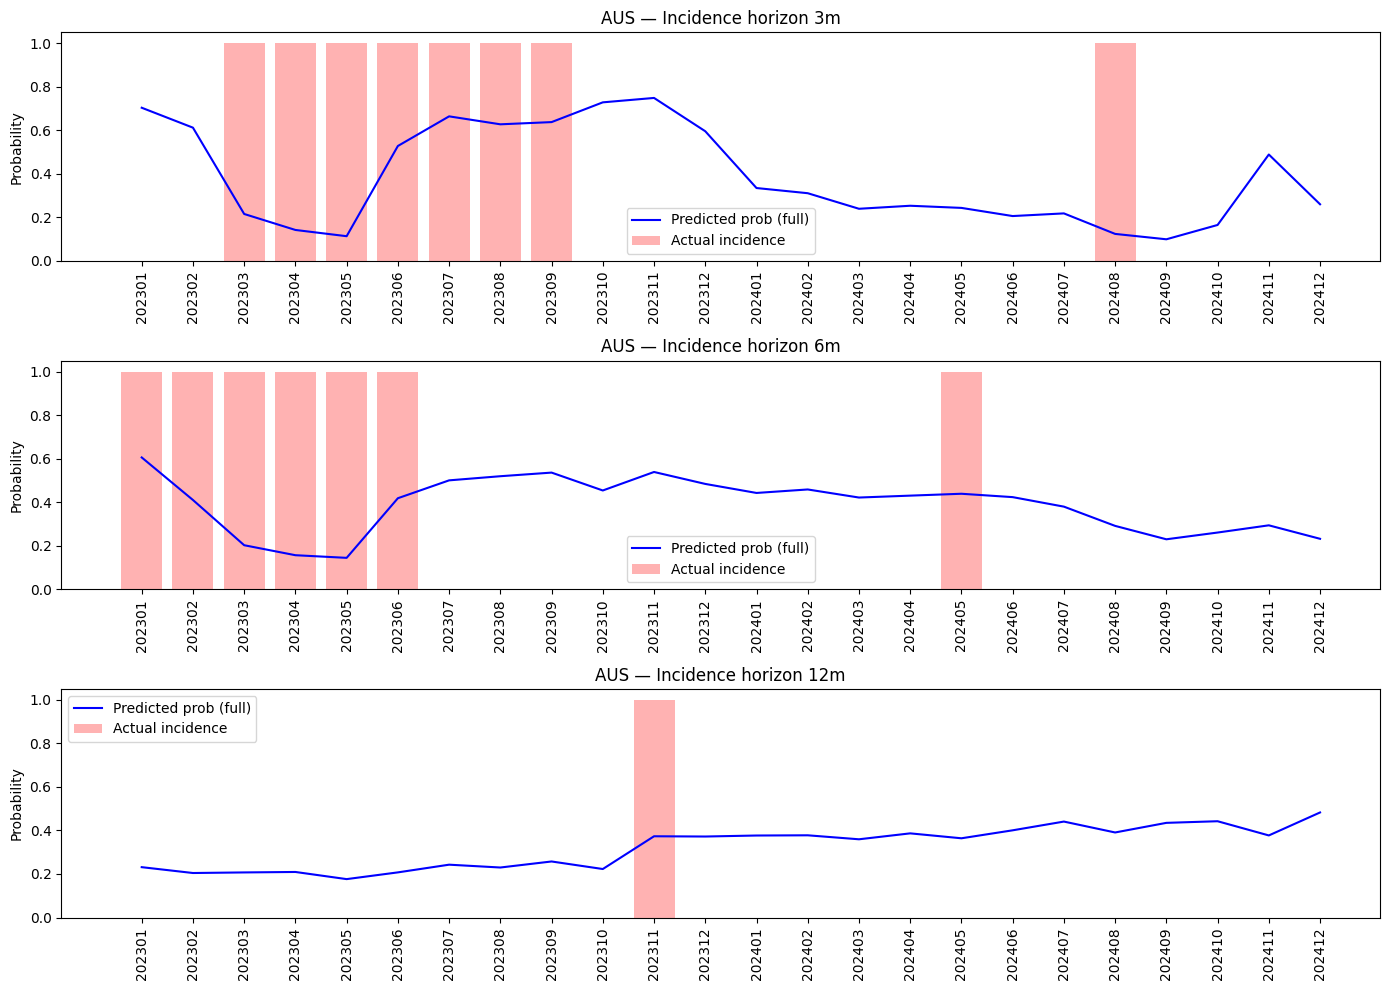

In [27]:
COUNTRY = 'AUS'

fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 10), sharex=False)

for i, h in enumerate(HORIZONS):
    ax = axes[i]
    df_plot = results[(h, 'full', 'incidence')]
    df_plot = df_plot.loc[df_plot.index.get_level_values('isocode') == COUNTRY].copy()
    df_plot = df_plot.reset_index()

    ax.bar(df_plot['period'].astype(str), df_plot['y_true'], alpha=0.3, color='red', label='Actual incidence')
    ax.plot(df_plot['period'].astype(str), df_plot['pred_prob'], color='blue', label='Predicted prob (full)')
    ax.set_title(f'{COUNTRY} — Incidence horizon {h}m')
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=90)
    ax.legend()

plt.tight_layout()
plt.show()


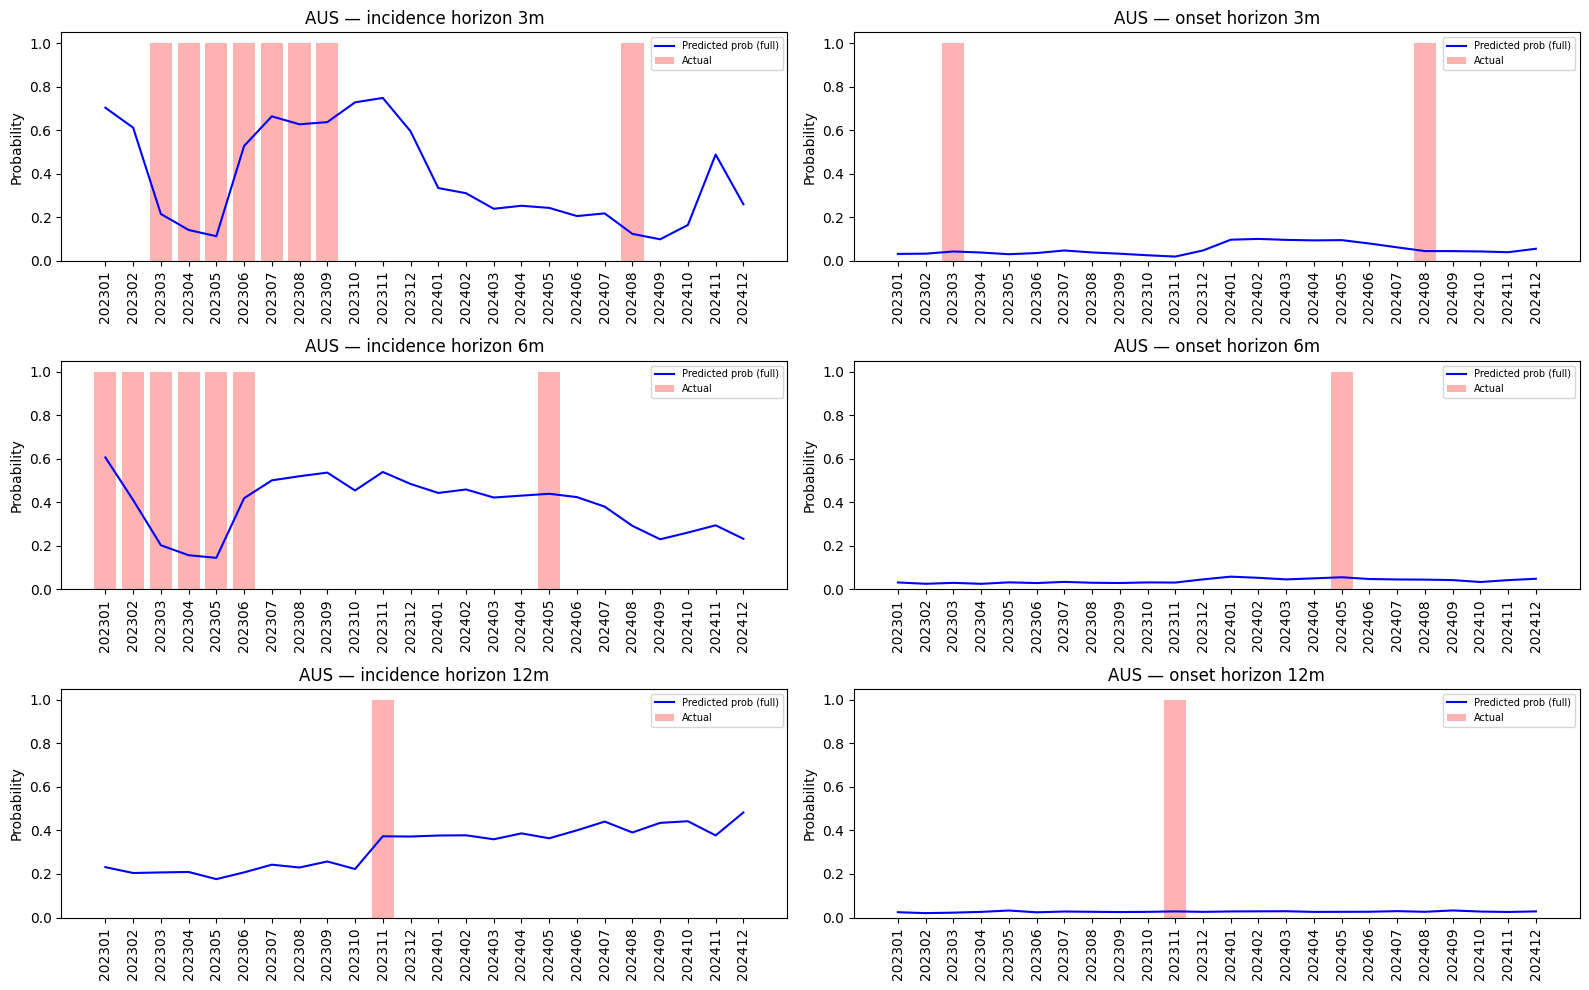

In [28]:
COUNTRY = 'AUS'

fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(16, 10), sharex=False)

for i, h in enumerate(HORIZONS):
    for j, target_name in enumerate(['incidence', 'onset']):
        ax = axes[i, j]
        df_plot = results[(h, 'full', target_name)]
        df_plot = df_plot.loc[df_plot.index.get_level_values('isocode') == COUNTRY].copy()
        df_plot = df_plot.reset_index()

        ax.bar(df_plot['period'].astype(str), df_plot['y_true'].fillna(0), alpha=0.3, color='red', label='Actual')
        ax.plot(df_plot['period'].astype(str), df_plot['pred_prob'], color='blue', label='Predicted prob (full)')
        ax.set_title(f'{COUNTRY} — {target_name} horizon {h}m')
        ax.set_ylabel('Probability')
        ax.tick_params(axis='x', rotation=90)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()


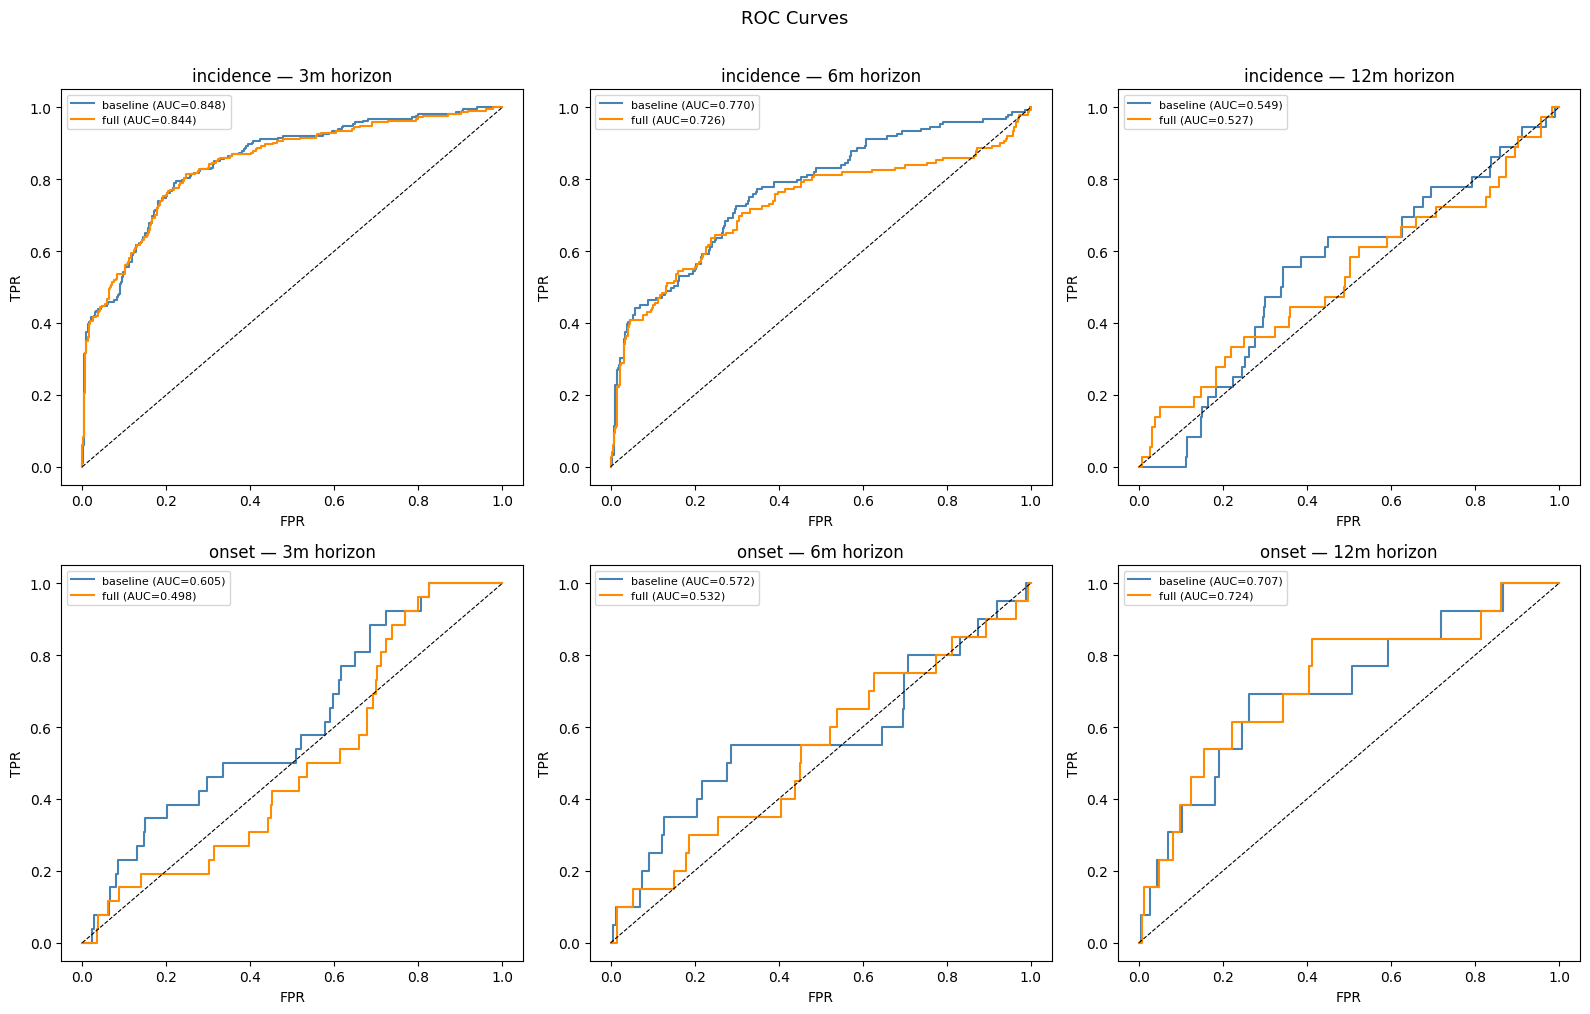

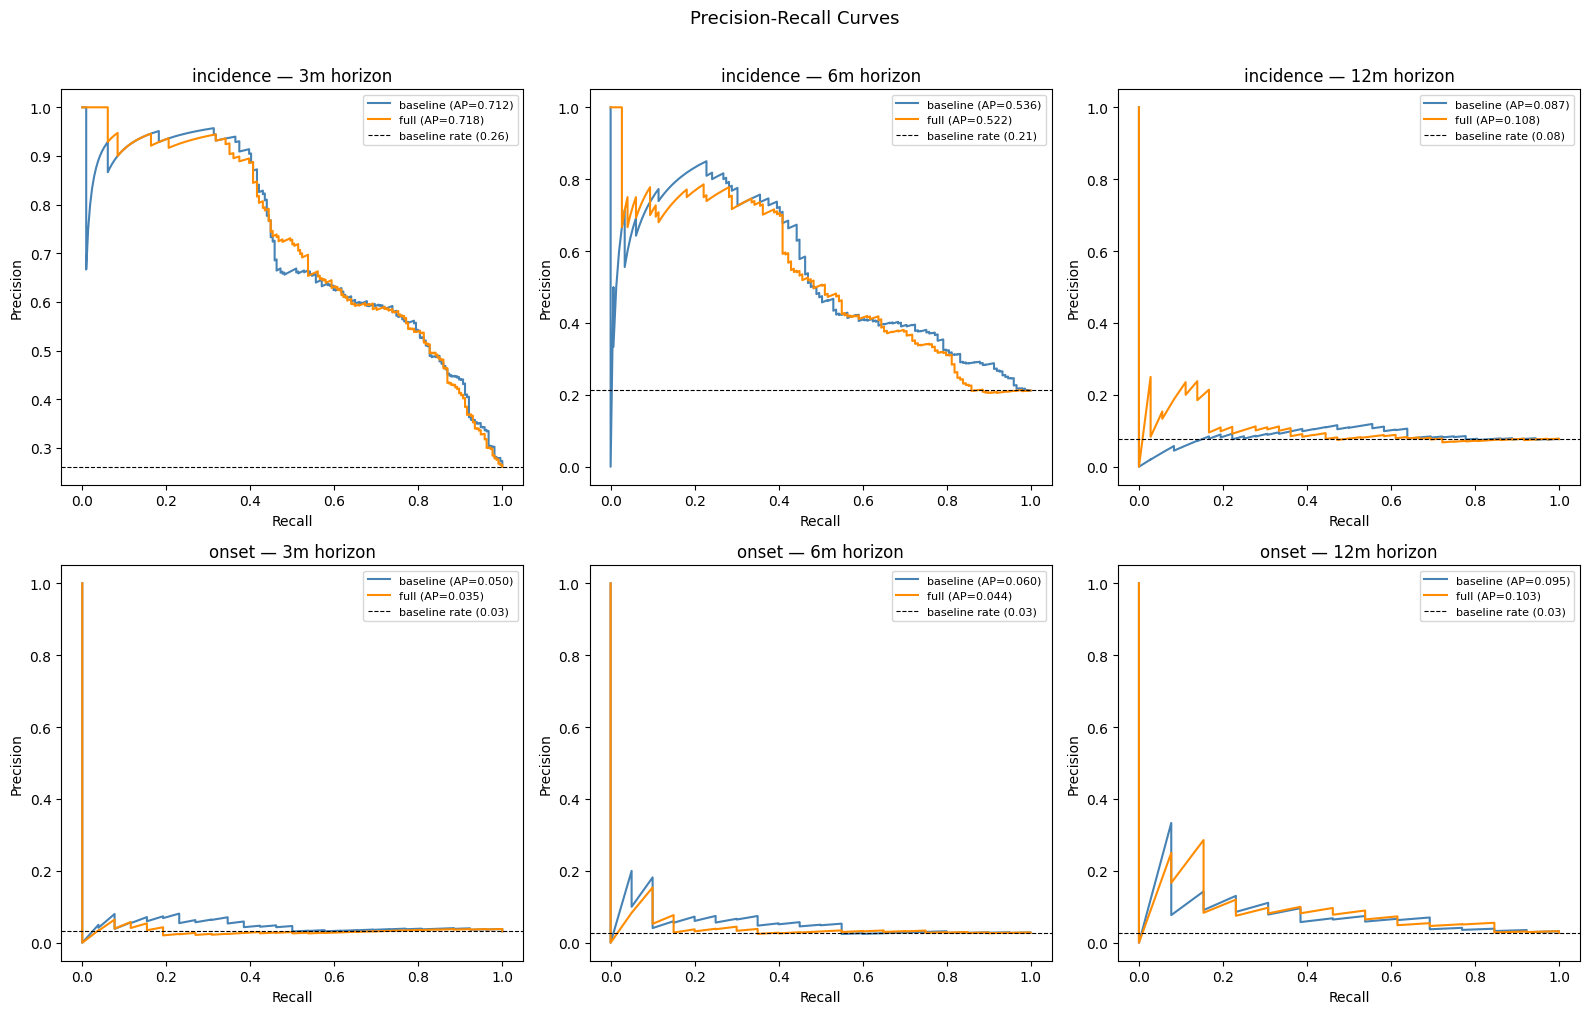

In [29]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

fig, axes = plt.subplots(2, len(HORIZONS), figsize=(16, 10))

for j, h in enumerate(HORIZONS):
    for target_name, row in [('incidence', 0), ('onset', 1)]:
        ax = axes[row, j]

        for model_name, color in [('baseline', 'steelblue'), ('full', 'darkorange')]:
            df_res = results[(h, model_name, target_name)].dropna(subset=['y_true', 'pred_prob'])
            y_true = df_res['y_true'].astype(float)
            y_pred = df_res['pred_prob']

            fpr, tpr, _ = roc_curve(y_true, y_pred)
            auc = roc_auc_score(y_true, y_pred)
            ax.plot(fpr, tpr, color=color, label=f'{model_name} (AUC={auc:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
        ax.set_title(f'{target_name} — {h}m horizon')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(fontsize=8)

plt.suptitle('ROC Curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Precision-Recall
fig, axes = plt.subplots(2, len(HORIZONS), figsize=(16, 10))

for j, h in enumerate(HORIZONS):
    for target_name, row in [('incidence', 0), ('onset', 1)]:
        ax = axes[row, j]

        for model_name, color in [('baseline', 'steelblue'), ('full', 'darkorange')]:
            df_res = results[(h, model_name, target_name)].dropna(subset=['y_true', 'pred_prob'])
            y_true = df_res['y_true'].astype(float)
            y_pred = df_res['pred_prob']

            precision, recall, _ = precision_recall_curve(y_true, y_pred)
            ap = average_precision_score(y_true, y_pred)
            ax.plot(recall, precision, color=color, label=f'{model_name} (AP={ap:.3f})')

        baseline_rate = y_true.mean()
        ax.axhline(baseline_rate, color='k', linestyle='--', linewidth=0.8, label=f'baseline rate ({baseline_rate:.2f})')
        ax.set_title(f'{target_name} — {h}m horizon')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.legend(fontsize=8)

plt.suptitle('Precision-Recall Curves', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Done: horizon=3m  model=baseline  target=incidence
Done: horizon=3m  model=baseline  target=onset
Done: horizon=3m  model=yield+macro  target=incidence
Done: horizon=3m  model=yield+macro  target=onset
Done: horizon=3m  model=yield+text  target=incidence
Done: horizon=3m  model=yield+text  target=onset
Done: horizon=3m  model=full  target=incidence
Done: horizon=3m  model=full  target=onset
Done: horizon=6m  model=baseline  target=incidence
Done: horizon=6m  model=baseline  target=onset
Done: horizon=6m  model=yield+macro  target=incidence
Done: horizon=6m  model=yield+macro  target=onset
Done: horizon=6m  model=yield+text  target=incidence
Done: horizon=6m  model=yield+text  target=onset
Done: horizon=6m  model=full  target=incidence
Done: horizon=6m  model=full  target=onset
Done: horizon=12m  model=baseline  target=incidence
Done: horizon=12m  model=baseline  target=onset
Done: horizon=12m  model=yield+macro  target=incidence
Done: horizon=12m  model=yield+macro  target=onset
Done: 

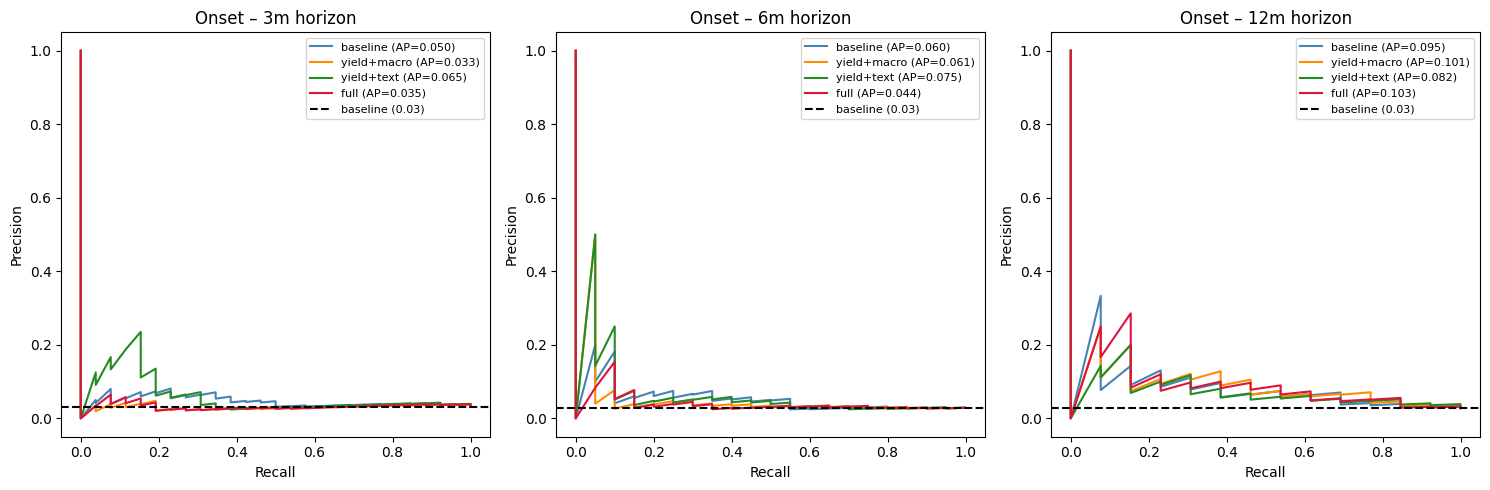

In [ ]:
# ============================================================
# BLOCK 1: Disaggregate macro vs. text contributions (FIXED)
# ============================================================
from sklearn.metrics import average_precision_score, precision_recall_curve

macro_cols = ['vix', 'brent_oil', 'credit_spread', 'inflation', 'fx_rate', 
              'stock_index', 'debt', 'ip', 'reserves', 'fatalities_UCDP']
topic_cols = [
    'Competition and Sports', 'Health and Education', 'Military Conflict',
    'Politics', 'Military Technology', 'National Development',
    'Political Tensions', 'Judiciary and Abuses', 'Middle East',
    'Chinese Politics', 'Economics', 'Diplomacy', 'Civilian Life',
    'Foreign Policy', 'Power and Negotiation'
]

feature_sets = {
    'baseline': yield_feature_cols,
    'yield+macro': yield_feature_cols + macro_cols,
    'yield+text': yield_feature_cols + topic_cols,
    'full': full_feature_cols
}

disagg_results = {}
rf = RandomForestClassifier(max_depth=4, max_features=0.2, min_samples_leaf=100, random_state=42)

for h in HORIZONS:
    cv = build_cv(gap=h)
    for model_name, feat_cols in feature_sets.items():
        X = df[feat_cols]
        for target_name in ['incidence', 'onset']:
            y = df[f'y_{target_name}_{h}m'].astype(float)
            preds, _ = cross_val_fit_predict(
                estimator=rf, X=X, y=y, cv=cv, method='predict_proba', drop_na_in_y=True
            )
            final_df = cv.gen_test_labels(
                df[[f'y_{target_name}_{h}m']].rename(columns={f'y_{target_name}_{h}m': 'y_true'})
            )
            final_df['pred_prob'] = preds[:, 1]
            final_df['horizon'] = h
            final_df['model'] = model_name
            final_df['target'] = target_name
            disagg_results[(h, model_name, target_name)] = final_df
            print(f"Done: horizon={h}m  model={model_name}  target={target_name}")

# Compare PR‑AUC on onset (with safety checks)
print("\n=== Disaggregated performance (PR‑AUC) ===")
for h in HORIZONS:
    print(f"\nHorizon {h}m – onset:")
    for model_name in feature_sets.keys():
        df_res = disagg_results[(h, model_name, 'onset')].dropna(subset=['y_true', 'pred_prob'])
        if df_res.empty:
            print(f"  {model_name:15s}: No valid predictions")
            continue
        y_true = df_res['y_true'].astype(int)
        y_pred = df_res['pred_prob']
        # average_precision_score requires at least one positive and one negative
        if y_true.nunique() < 2:
            print(f"  {model_name:15s}: Only one class present, AP = N/A")
        else:
            ap = average_precision_score(y_true, y_pred)
            print(f"  {model_name:15s}: AP = {ap:.4f}")

# Plot PR curves for onset (skip if no data)
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 5))
for j, h in enumerate(HORIZONS):
    ax = axes[j]
    plotted = False
    for model_name, color in zip(feature_sets.keys(), ['steelblue', 'darkorange', 'forestgreen', 'crimson']):
        df_res = disagg_results[(h, model_name, 'onset')].dropna(subset=['y_true', 'pred_prob'])
        if df_res.empty:
            continue
        y_true = df_res['y_true'].astype(int)
        y_pred = df_res['pred_prob']
        if y_true.nunique() < 2:
            continue
        precision, recall, _ = precision_recall_curve(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        ax.plot(recall, precision, color=color, label=f'{model_name} (AP={ap:.3f})')
        plotted = True
    if plotted:
        # baseline rate (use the first non‑empty df_res)
        baseline_rate = y_true.mean()
        ax.axhline(baseline_rate, color='k', linestyle='--', label=f'baseline ({baseline_rate:.2f})')
        ax.set_title(f'Onset – {h}m horizon')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

No previously engineered columns found.
Added 109 engineered features. Total columns now: 161
Original full model had 39 features.
Pruned engineered model has 149 features.
Enhanced model done: horizon=3m
Enhanced model done: horizon=6m
Enhanced model done: horizon=12m

=== PR‑AUC comparison (onset) ===
Horizon 3m: Original AP = 0.0350  |  Enhanced AP = 0.0383  |  Improvement = 0.0033
Horizon 6m: Original AP = 0.0437  |  Enhanced AP = 0.0871  |  Improvement = 0.0434
Horizon 12m: Original AP = 0.1029  |  Enhanced AP = 0.1076  |  Improvement = 0.0046


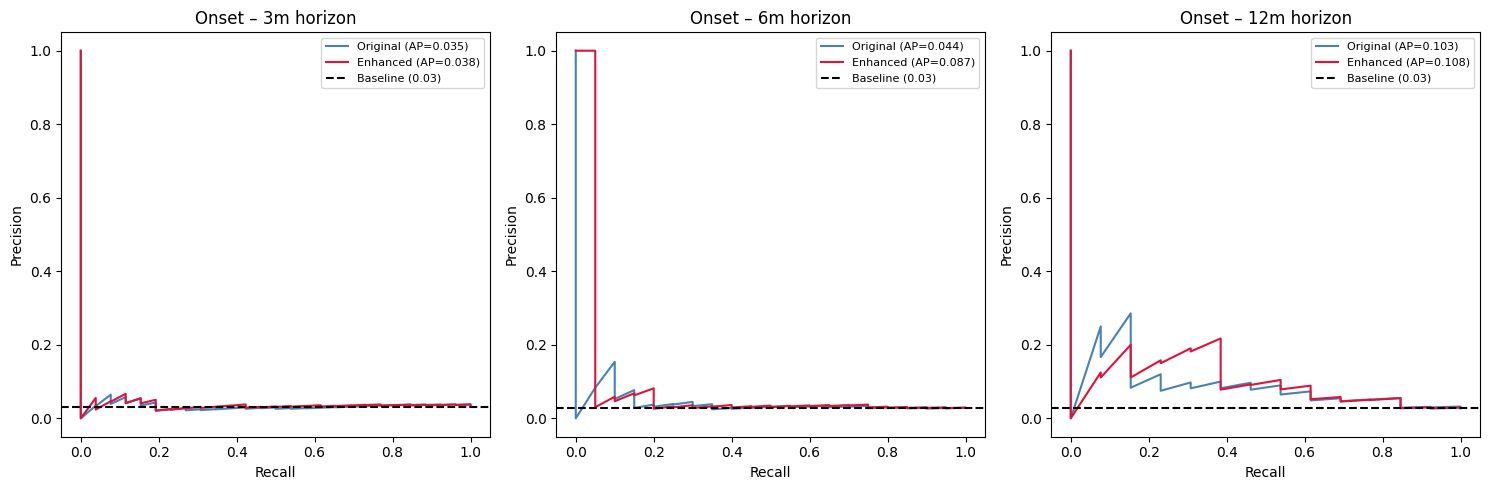

In [46]:
# ============================================================
# BLOCK 2 (Fully corrected, safe for re-runs)
# ============================================================
from sklearn.metrics import average_precision_score, precision_recall_curve
import pandas as pd

# ---- Step 0: Remove only previously engineered macro/topic columns ----
# Identify columns that were added by previous runs of this block
# They follow patterns: var_lagX, var_rm_start_end, var_stock
macro_vars = ['vix', 'brent_oil', 'credit_spread', 'inflation', 'fx_rate', 
              'stock_index', 'debt', 'ip', 'reserves', 'fatalities_UCDP']
topic_vars = topic_cols  # already defined earlier
all_vars = macro_vars + topic_vars

# Build regex pattern to match columns we might have added
import re
pattern = r'^(' + '|'.join(re.escape(v) for v in all_vars) + r')_(lag|rm_|stock)'
cols_to_drop = [col for col in df.columns if re.match(pattern, col)]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Removed {len(cols_to_drop)} previously engineered columns. Now df has {df.shape[1]} columns.")
else:
    print("No previously engineered columns found.")

# ----- Granger-based thresholds (same as before) -----
macro_overall_pct = {
    'inflation': 26.58, 'reserves': 20.09, 'credit_spread': 15.63,
    'stock_index': 13.49, 'brent_oil': 11.77, 'debt': 10.83,
    'fx_rate': 8.99, 'ip': 7.41, 'vix': 5.94, 'fatalities_UCDP': 4.95
}
topic_overall_pct = {
    'Chinese Politics': 10.83, 'Health and Education': 10.52, 'Diplomacy': 9.17,
    'Political Tensions': 8.85, 'Military Technology': 8.23, 'Competition and Sports': 8.13,
    'Politics': 8.13, 'Economics': 7.40, 'Power and Negotiation': 7.40,
    'Military Conflict': 7.29, 'National Development': 6.88, 'Foreign Policy': 5.10,
    'Middle East': 5.00, 'Civilian Life': 4.90, 'Judiciary and Abuses': 2.81
}

lag_threshold = 8.0
lags_to_keep = {}
for var in macro_vars + topic_vars:
    pct = macro_overall_pct.get(var, topic_overall_pct.get(var, 0))
    lags_to_keep[var] = [1,3,6,12] if pct > lag_threshold else []

# Chunked significance (4-month windows)
macro_chunk_pct = {
    'inflation':      [27.70, 25.68, 27.03, 30.41, 22.97, 25.68],
    'reserves':       [3.85,  5.77,  18.59, 27.56, 28.85, 35.90],
    'credit_spread':  [20.63, 16.25, 15.63, 16.88, 11.88, 12.50],
    'stock_index':    [9.87,  9.87,  12.50, 15.79, 16.45, 16.45],
    'brent_oil':      [11.88, 19.38, 15.63, 9.38,  6.88,  7.50],
    'debt':           [8.57,  12.14, 15.71, 12.14, 7.86,  8.57],
    'fx_rate':        [9.87,  13.16, 8.55,  8.55,  8.55,  5.26],
    'ip':             [7.64,  4.86,  6.25,  8.33,  7.64,  9.72],
    'vix':            [10.63, 3.75,  5.00,  4.38,  2.50,  9.38],
    'fatalities_UCDP':[10.94, 12.50, 3.13,  3.13,  0.00,  0.00]
}
topic_chunk_pct = {
    'Chinese Politics':     [4.38,  8.75,  14.38, 14.38, 15.00, 8.13],
    'Health and Education': [4.38,  3.13,  3.75,  12.50, 16.88, 22.50],
    'Diplomacy':            [8.75,  6.88,  15.00, 10.00, 8.13,  6.25],
    'Political Tensions':   [10.63, 13.75, 8.13,  5.63,  7.50,  7.50],
    'Military Technology':  [6.25,  7.50,  8.13,  8.75,  11.88, 6.88],
    'Competition and Sports':[8.75, 6.88,  6.88,  6.88,  11.88, 7.50],
    'Politics':             [3.75,  10.00, 10.63, 6.88,  9.38,  8.13],
    'Economics':            [3.75,  3.75,  5.00,  5.00,  12.50, 14.38],
    'Power and Negotiation':[8.13,  4.38,  6.88,  8.75,  8.13,  8.13],
    'Military Conflict':    [5.00,  6.25,  10.00, 8.75,  6.25,  7.50],
    'National Development': [9.38,  8.13,  9.38,  5.00,  5.00,  4.38],
    'Foreign Policy':       [2.50,  6.88,  4.38,  3.75,  8.75,  4.38],
    'Middle East':          [5.00,  4.38,  6.25,  3.75,  5.63,  5.00],
    'Civilian Life':        [4.38,  5.63,  5.63,  4.38,  5.00,  4.38],
    'Judiciary and Abuses': [3.75,  4.38,  0.63,  2.50,  4.38,  1.25]
}
windows = [(1,4), (5,8), (9,12), (13,16), (17,20), (21,24)]
window_threshold = 10.0

keep_windows = {}
for var in macro_vars + topic_vars:
    chunks = macro_chunk_pct.get(var, topic_chunk_pct.get(var, [0]*6))
    keep = []
    for i, (start, end) in enumerate(windows):
        if chunks[i] > window_threshold:
            keep.append((start, end))
    keep_windows[var] = keep

# ----- Build new features efficiently -----
new_features_list = []
new_feature_names = []

# 1) Lags
for var in macro_vars + topic_vars:
    for lag in lags_to_keep.get(var, []):
        col_name = f'{var}_lag{lag}'
        new_features_list.append(df.groupby(level='isocode')[var].transform(lambda s: s.shift(lag)))
        new_feature_names.append(col_name)

# 2) Rolling means (backward-looking, excluding current month)
for var in macro_vars + topic_vars:
    for start, end in keep_windows.get(var, []):
        col_name = f'{var}_rm_{start}_{end}'
        width = end - start + 1
        # shift = start (so month start-1 is the first included, current month excluded)
        new_features_list.append(
            df.groupby(level='isocode')[var].transform(
                lambda s, shift=start: s.shift(shift).rolling(width).mean()
            )
        )
        new_feature_names.append(col_name)

# 3) Exponential stocks for macro variables (overall > 5%)
delta = 0.8
for var in macro_vars:
    if macro_overall_pct.get(var, 0) > 5.0:
        def compute_stock(series):
            stock = 0.0
            stocks = []
            for val in series:
                stock = delta * stock + (val if pd.notna(val) else 0)
                stocks.append(stock)
            return stocks
        col_name = f'{var}_stock'
        new_features_list.append(df.groupby(level='isocode')[var].transform(compute_stock))
        new_feature_names.append(col_name)

# Concatenate all new features
if new_features_list:
    new_features_df = pd.concat(new_features_list, axis=1)
    new_features_df.columns = new_feature_names
    df = pd.concat([df, new_features_df], axis=1)
    print(f"Added {len(new_feature_names)} engineered features. Total columns now: {df.shape[1]}")
else:
    print("No new features were added (thresholds too high or no variables qualified).")

# ----- Final feature set -----
final_feature_cols = yield_feature_cols + macro_vars + topic_vars + new_feature_names
final_feature_cols = list(dict.fromkeys(final_feature_cols))  # unique

print(f"Original full model had {len(full_feature_cols)} features.")
print(f"Pruned engineered model has {len(final_feature_cols)} features.")

# ----- Cross-validation with new features -----
enhanced_results = {}
rf2 = RandomForestClassifier(max_depth=4, max_features=0.2, min_samples_leaf=100, random_state=42)

for h in HORIZONS:
    cv = build_cv(gap=h)
    X = df[final_feature_cols]
    target_name = 'onset'
    y = df[f'y_{target_name}_{h}m'].astype(float)
    preds, _ = cross_val_fit_predict(
        estimator=rf2, X=X, y=y, cv=cv, method='predict_proba', drop_na_in_y=True
    )
    final_df = cv.gen_test_labels(
        df[[f'y_{target_name}_{h}m']].rename(columns={f'y_{target_name}_{h}m': 'y_true'})
    )
    final_df['pred_prob'] = preds[:, 1]
    final_df['horizon'] = h
    enhanced_results[h] = final_df
    print(f"Enhanced model done: horizon={h}m")

# ----- Compare with original -----
print("\n=== PR‑AUC comparison (onset) ===")
for h in HORIZONS:
    df_orig = results[(h, 'full', 'onset')].dropna(subset=['y_true', 'pred_prob'])
    if not df_orig.empty:
        y_true_orig = df_orig['y_true'].astype(int)
        if y_true_orig.nunique() >= 2:
            ap_orig = average_precision_score(y_true_orig, df_orig['pred_prob'])
        else:
            ap_orig = float('nan')
    else:
        ap_orig = float('nan')
    
    df_enh = enhanced_results[h].dropna(subset=['y_true', 'pred_prob'])
    if not df_enh.empty:
        y_true_enh = df_enh['y_true'].astype(int)
        if y_true_enh.nunique() >= 2:
            ap_enh = average_precision_score(y_true_enh, df_enh['pred_prob'])
        else:
            ap_enh = float('nan')
    else:
        ap_enh = float('nan')
    
    print(f"Horizon {h}m: Original AP = {ap_orig:.4f}  |  Enhanced AP = {ap_enh:.4f}  |  Improvement = {ap_enh - ap_orig:.4f}")

# Plot PR curves (optional)
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 5))
for j, h in enumerate(HORIZONS):
    ax = axes[j]
    plotted = False
    df_orig = results[(h, 'full', 'onset')].dropna(subset=['y_true', 'pred_prob'])
    if not df_orig.empty:
        y_true = df_orig['y_true'].astype(int)
        if y_true.nunique() >= 2:
            precision, recall, _ = precision_recall_curve(y_true, df_orig['pred_prob'])
            ap_orig = average_precision_score(y_true, df_orig['pred_prob'])
            ax.plot(recall, precision, color='steelblue', label=f'Original (AP={ap_orig:.3f})')
            plotted = True
    df_enh = enhanced_results[h].dropna(subset=['y_true', 'pred_prob'])
    if not df_enh.empty:
        y_true = df_enh['y_true'].astype(int)
        if y_true.nunique() >= 2:
            precision, recall, _ = precision_recall_curve(y_true, df_enh['pred_prob'])
            ap_enh = average_precision_score(y_true, df_enh['pred_prob'])
            ax.plot(recall, precision, color='crimson', label=f'Enhanced (AP={ap_enh:.3f})')
            plotted = True
    if plotted:
        base = df_orig['y_true'].astype(int) if not df_orig.empty else df_enh['y_true'].astype(int)
        baseline_rate = base.mean()
        ax.axhline(baseline_rate, color='k', linestyle='--', label=f'Baseline ({baseline_rate:.2f})')
        ax.set_title(f'Onset – {h}m horizon')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()